In [26]:
# ============================================================
# EXPERIMENT 5
# Decision Tree Classifier using ID3 Algorithm
# Online Retail Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [41]:
#import pandas as pd

#df = pd.read_excel("Online Retail.xlsx", engine="openpyxl")

#print(df.shape)
#print(df.head())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [56]:
df = pd.read_csv("OnlineRetail.csv",encoding="ISO-8859-1")
print(df.shape)
print(df.head())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [57]:

# ------------------------------------------------------------
# 2. PREPROCESS THE DATA
# ------------------------------------------------------------

# Remove rows where CustomerID is missing
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantity and price values
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert CustomerID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

# Calculate total amount for each transaction
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("\nDataset after preprocessing:", df.shape)


Dataset after preprocessing: (397884, 9)


In [58]:
# ------------------------------------------------------------
# 3. CONVERT TRANSACTION DATA TO CUSTOMER DATA
# ------------------------------------------------------------

customer_data = df.groupby("CustomerID").agg(
    Total_Spending=("TotalAmount", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Number_of_Purchases=("InvoiceNo", "nunique"),
    Number_of_Products=("StockCode", "nunique"),
    Average_Transaction_Value=("TotalAmount", "mean")
).reset_index()

print("\nCustomer-Level Data:")
print(customer_data.head())


Customer-Level Data:
   CustomerID  Total_Spending  Total_Quantity  Number_of_Purchases  \
0       12346        77183.60           74215                    1   
1       12347         4310.00            2458                    7   
2       12348         1797.24            2341                    4   
3       12349         1757.55             631                    1   
4       12350          334.40             197                    1   

   Number_of_Products  Average_Transaction_Value  
0                   1               77183.600000  
1                 103                  23.681319  
2                  22                  57.975484  
3                  73                  24.076027  
4                  17                  19.670588  


In [59]:
# ------------------------------------------------------------
# 4. CREATE CUSTOMER CATEGORIES
# ------------------------------------------------------------

# Divide customers into three groups based on spending:
# Low, Medium and High

customer_data["Customer_Category"] = pd.qcut(
    customer_data["Total_Spending"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

print("\nCustomer Category Distribution:")
print(customer_data["Customer_Category"].value_counts())


Customer Category Distribution:
Customer_Category
Low       1446
Medium    1446
High      1446
Name: count, dtype: int64


In [60]:
# ------------------------------------------------------------
# 5. SELECT FEATURES
# ------------------------------------------------------------

# IMPORTANT:
# Total_Spending is NOT used as an input feature because
# Customer_Category was created directly from Total_Spending.
# Including it would cause data leakage.

features = [
    "Total_Quantity",
    "Number_of_Purchases",
    "Number_of_Products",
    "Average_Transaction_Value"
]

X = customer_data[features]
y = customer_data["Customer_Category"].astype(str)

In [61]:
# ------------------------------------------------------------
# 6. SPLIT DATA
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
# ------------------------------------------------------------
# 7. ID3 DECISION TREE
# ------------------------------------------------------------

# criterion="entropy" uses entropy/information gain,
# which is the splitting criterion used by ID3.

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [63]:
# ------------------------------------------------------------
# 8. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 84.68 %

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.87      0.90       289
         Low       0.87      0.85      0.86       289
      Medium       0.75      0.82      0.78       290

    accuracy                           0.85       868
   macro avg       0.85      0.85      0.85       868
weighted avg       0.85      0.85      0.85       868



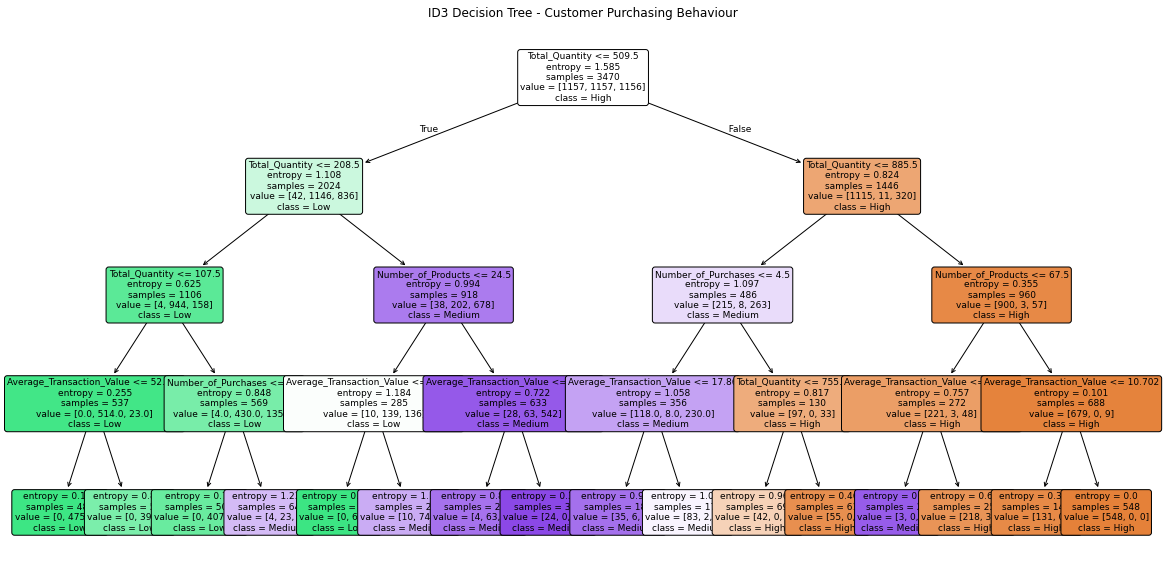

In [64]:
# ------------------------------------------------------------
# 9. VISUALIZE DECISION TREE
# ------------------------------------------------------------

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=features,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("ID3 Decision Tree - Customer Purchasing Behaviour")
plt.show()

In [65]:
# ------------------------------------------------------------
# 10. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
                     Feature  Importance
0             Total_Quantity    0.851269
3  Average_Transaction_Value    0.072278
2         Number_of_Products    0.050347
1        Number_of_Purchases    0.026105


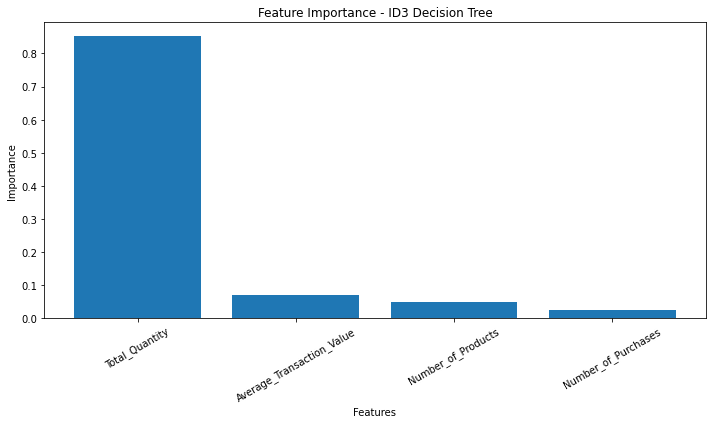

In [66]:
# ------------------------------------------------------------
# 11. FEATURE IMPORTANCE GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - ID3 Decision Tree")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [67]:
# ------------------------------------------------------------
# 12. DISPLAY DECISION RULES
# ------------------------------------------------------------

rules = export_text(
    model,
    feature_names=features
)

print("\n========== DECISION RULES ==========")
print(rules)

print("\n========== EXPERIMENT RESULT ==========")
print("ID3 Decision Tree was successfully implemented.")
print("Customer purchasing behaviour was classified into Low, Medium, and High categories.")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("\nThe feature importance values show which purchasing")
print("features have the greatest influence on customer classification.")


========== DECISION RULES ==========
|--- Total_Quantity <= 509.50
|   |--- Total_Quantity <= 208.50
|   |   |--- Total_Quantity <= 107.50
|   |   |   |--- Average_Transaction_Value <= 52.63
|   |   |   |   |--- class: Low
|   |   |   |--- Average_Transaction_Value >  52.63
|   |   |   |   |--- class: Low
|   |   |--- Total_Quantity >  107.50
|   |   |   |--- Number_of_Purchases <= 2.50
|   |   |   |   |--- class: Low
|   |   |   |--- Number_of_Purchases >  2.50
|   |   |   |   |--- class: Medium
|   |--- Total_Quantity >  208.50
|   |   |--- Number_of_Products <= 24.50
|   |   |   |--- Average_Transaction_Value <= 16.57
|   |   |   |   |--- class: Low
|   |   |   |--- Average_Transaction_Value >  16.57
|   |   |   |   |--- class: Medium
|   |   |--- Number_of_Products >  24.50
|   |   |   |--- Average_Transaction_Value <= 14.64
|   |   |   |   |--- class: Medium
|   |   |   |--- Average_Transaction_Value >  14.64
|   |   |   |   |--- class: Medium
|--- Total_Quantity >  509.50
|   |-